In [8]:
import os 
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from image_stitching import models
import utils.plot_utils as pu
import utils.file_utils as fu
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# View Connectivity of Images

In [9]:
Pano = models.Panorama("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data/myself")
_ = Pano.detect()
_ = Pano.match_all_images()

In [10]:
Pano.matching_df[0:10]

,Descriptor,ImgId,Matched_Ids,Distances,Matched_ImgIds
0,"[55, 98, 68, 133, 46, 2, 206, 120, 0, 226, 213...",0,"[2004, 939, 1734, 2125, 3827, 4311]","[69.0, 70.0, 71.0, 71.0, 71.0, 71.0]","[4, 1, 3, 4, 7, 8]"
1,"[115, 110, 107, 37, 32, 201, 79, 226, 169, 228...",0,"[2531, 2949, 5434, 4234, 4280, 4542]","[83.0, 86.0, 87.0, 88.0, 88.0, 89.0]","[5, 5, 10, 8, 8, 9]"
2,"[120, 205, 142, 251, 157, 242, 230, 231, 85, 1...",0,"[2706, 4295, 4370, 1077, 1034, 3193, 4377]","[58.0, 62.0, 66.0, 68.0, 69.0, 69.0, 69.0]","[5, 8, 8, 2, 2, 6, 8]"
3,"[7, 180, 157, 83, 24, 175, 169, 156, 174, 113,...",0,"[5088, 5430, 4466, 528, 653, 1614, 2443, 2776]","[77.0, 77.0, 80.0, 85.0, 85.0, 85.0, 87.0, 87.0]","[10, 10, 8, 1, 1, 3, 4, 5]"
4,"[23, 125, 73, 164, 10, 195, 79, 226, 39, 224, ...",0,"[2645, 2533, 3828, 989, 1465, 3626, 3564]","[75.0, 78.0, 79.0, 81.0, 81.0, 81.0, 82.0]","[5, 5, 7, 1, 2, 7, 7]"
5,"[220, 163, 157, 178, 168, 15, 76, 189, 174, 18...",0,"[5055, 5244, 3404, 1084, 3062, 4144]","[67.0, 70.0, 72.0, 73.0, 75.0, 76.0]","[10, 10, 6, 2, 6, 8]"
6,"[213, 98, 121, 71, 52, 10, 239, 156, 100, 224,...",0,"[3226, 4219, 3163, 4094, 2056, 3079]","[46.0, 62.0, 63.0, 63.0, 64.0, 64.0]","[6, 8, 6, 8, 4, 6]"
7,"[103, 113, 183, 76, 205, 45, 119, 216, 171, 24...",0,"[5290, 5426, 3140, 4644]","[67.0, 70.0, 82.0, 83.0]","[10, 10, 6, 9]"
8,"[64, 48, 189, 180, 12, 100, 84, 15, 138, 178, ...",0,"[4664, 532, 4761, 985]","[61.0, 71.0, 72.0, 73.0]","[9, 1, 9, 1]"
9,"[101, 229, 233, 65, 156, 79, 199, 141, 66, 181...",0,"[1318, 853, 4273, 4296]","[68.0, 69.0, 71.0, 72.0]","[2, 1, 8, 8]"


In [16]:
Pano.get_number_of_matches_per_image_pair()

,ImgId,MatchedWith,Count
0,0,1,359
1,0,2,234
2,0,3,321
3,0,4,247
4,0,5,199
...,...,...,...
105,10,5,222
106,10,6,244
107,10,7,494
108,10,8,241


In [17]:
Pano.get_number_of_good_matches_per_image_pair()

,ImgId,MatchedWith,Count
0,0,1,32
1,0,2,22
2,0,3,46
3,0,4,24
4,0,5,27
...,...,...,...
105,10,5,50
106,10,6,42
107,10,7,202
108,10,8,55


In [14]:
print(Pano.get_matching_stats_string2())

0 | medium08.jpg
	8 | medium07.jpg | 78.0 | 0.16
	1 | medium11.jpg | 32.0 | 0.06
	6 | medium10.jpg | 27.0 | 0.05
	10 | medium01.jpg | 36.0 | 0.07
	3 | medium09.jpg | 46.0 | 0.09
	7 | medium02.jpg | 33.0 | 0.07
	9 | medium06.jpg | 24.0 | 0.05
	4 | medium03.jpg | 24.0 | 0.05
	2 | medium04.jpg | 22.0 | 0.04
	5 | medium05.jpg | 27.0 | 0.05

1 | medium11.jpg
	10 | medium01.jpg | 217.0 | 0.43
	6 | medium10.jpg | 123.0 | 0.25
	0 | medium08.jpg | 53.0 | 0.11
	7 | medium02.jpg | 51.0 | 0.10
	8 | medium07.jpg | 47.0 | 0.09
	3 | medium09.jpg | 42.0 | 0.08
	2 | medium04.jpg | 27.0 | 0.05
	4 | medium03.jpg | 25.0 | 0.05
	9 | medium06.jpg | 43.0 | 0.09
	5 | medium05.jpg | 38.0 | 0.08

2 | medium04.jpg
	5 | medium05.jpg | 256.0 | 0.51
	4 | medium03.jpg | 242.0 | 0.48
	8 | medium07.jpg | 77.0 | 0.15
	7 | medium02.jpg | 90.0 | 0.18
	10 | medium01.jpg | 63.0 | 0.13
	9 | medium06.jpg | 50.0 | 0.10
	0 | medium08.jpg | 43.0 | 0.09
	3 | medium09.jpg | 56.0 | 0.11
	6 | medium10.jpg | 41.0 | 0.08
	1 | medium1

In [15]:
print(Pano.get_matching_stats_string())

0 | medium08.jpg
	8 | medium07.jpg | 78.0 | 0.16
	3 | medium09.jpg | 46.0 | 0.09
	10 | medium01.jpg | 36.0 | 0.07
	7 | medium02.jpg | 33.0 | 0.07
	1 | medium11.jpg | 32.0 | 0.06
	5 | medium05.jpg | 27.0 | 0.05
	6 | medium10.jpg | 27.0 | 0.05
	4 | medium03.jpg | 24.0 | 0.05
	9 | medium06.jpg | 24.0 | 0.05
	2 | medium04.jpg | 22.0 | 0.04

1 | medium11.jpg
	10 | medium01.jpg | 217.0 | 0.43
	6 | medium10.jpg | 123.0 | 0.25
	0 | medium08.jpg | 53.0 | 0.11
	7 | medium02.jpg | 51.0 | 0.10
	8 | medium07.jpg | 47.0 | 0.09
	9 | medium06.jpg | 43.0 | 0.09
	3 | medium09.jpg | 42.0 | 0.08
	5 | medium05.jpg | 38.0 | 0.08
	2 | medium04.jpg | 27.0 | 0.05
	4 | medium03.jpg | 25.0 | 0.05

2 | medium04.jpg
	5 | medium05.jpg | 256.0 | 0.51
	4 | medium03.jpg | 242.0 | 0.48
	7 | medium02.jpg | 90.0 | 0.18
	8 | medium07.jpg | 77.0 | 0.15
	10 | medium01.jpg | 63.0 | 0.13
	3 | medium09.jpg | 56.0 | 0.11
	1 | medium11.jpg | 53.0 | 0.11
	9 | medium06.jpg | 50.0 | 0.10
	0 | medium08.jpg | 43.0 | 0.09
	6 | medium1

In [12]:
print(Pano.get_matching_stats_string())

0 | medium08.jpg
	8 | medium07.jpg | 78.0 | 0.16
	1 | medium11.jpg | 32.0 | 0.06
	6 | medium10.jpg | 27.0 | 0.05
	10 | medium01.jpg | 36.0 | 0.07
	3 | medium09.jpg | 46.0 | 0.09
	7 | medium02.jpg | 33.0 | 0.07
	9 | medium06.jpg | 24.0 | 0.05
	4 | medium03.jpg | 24.0 | 0.05
	2 | medium04.jpg | 22.0 | 0.04
	5 | medium05.jpg | 27.0 | 0.05

1 | medium11.jpg
	10 | medium01.jpg | 217.0 | 0.43
	6 | medium10.jpg | 123.0 | 0.25
	0 | medium08.jpg | 53.0 | 0.11
	7 | medium02.jpg | 51.0 | 0.10
	8 | medium07.jpg | 47.0 | 0.09
	3 | medium09.jpg | 42.0 | 0.08
	2 | medium04.jpg | 27.0 | 0.05
	4 | medium03.jpg | 25.0 | 0.05
	9 | medium06.jpg | 43.0 | 0.09
	5 | medium05.jpg | 38.0 | 0.08

2 | medium04.jpg
	5 | medium05.jpg | 256.0 | 0.51
	4 | medium03.jpg | 242.0 | 0.48
	8 | medium07.jpg | 77.0 | 0.15
	7 | medium02.jpg | 90.0 | 0.18
	10 | medium01.jpg | 63.0 | 0.13
	9 | medium06.jpg | 50.0 | 0.10
	0 | medium08.jpg | 43.0 | 0.09
	3 | medium09.jpg | 56.0 | 0.11
	6 | medium10.jpg | 41.0 | 0.08
	1 | medium1

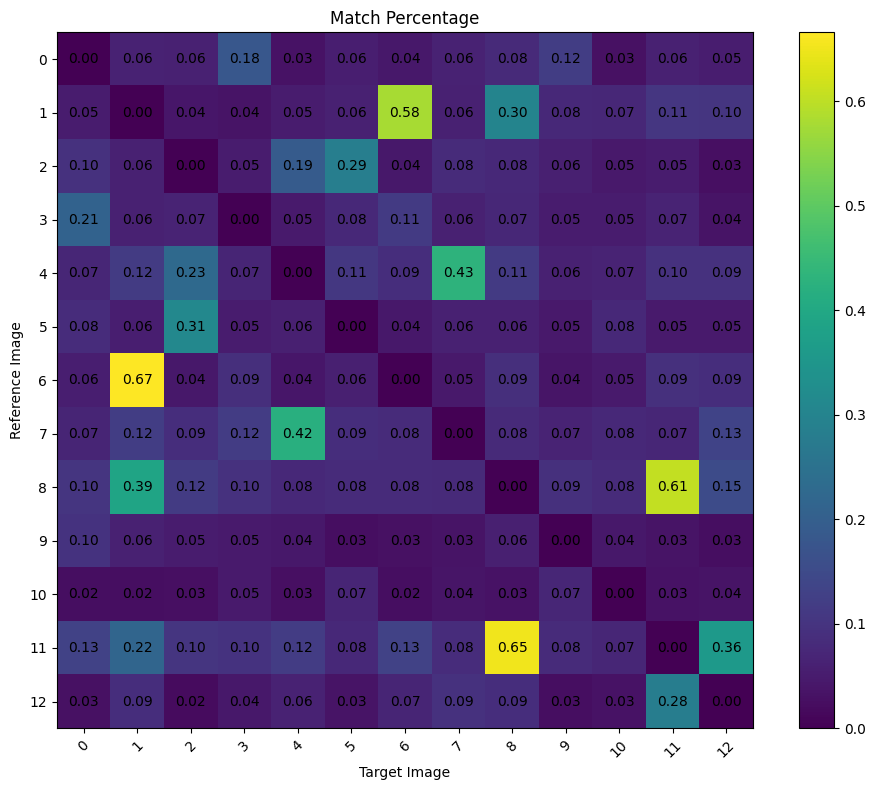

In [86]:
M_ratio = Pano.match_ratio_matrix()
pu.plot_connectivity_matrix(M_ratio)

Is fully connected:  True
Best base node:  8


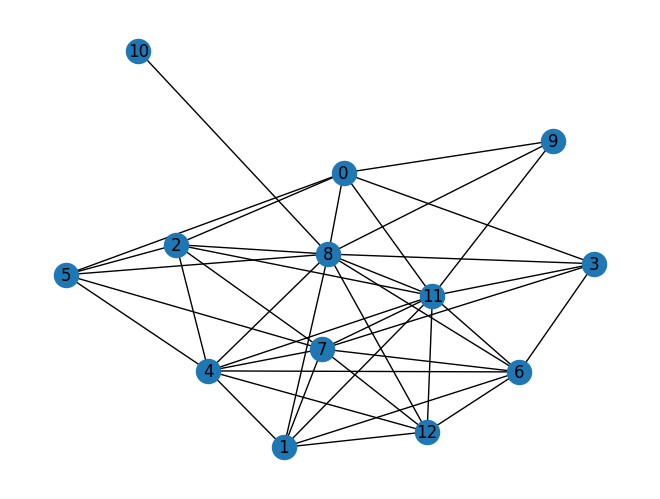

In [87]:
PG = models.PanoramaGraph(match_threshold=0.08)
PG.initialize_graph(M_ratio)
print("Is fully connected: ", PG.fully_connected)
print("Best base node: ", PG.base_node)
pu.plot_panorama_graph(PG)

# View Stages of the Panorama Graph

1. After establishing finding pssoible connections (PG.initialize_graph(M))
2. After estabsling true connections with inliers

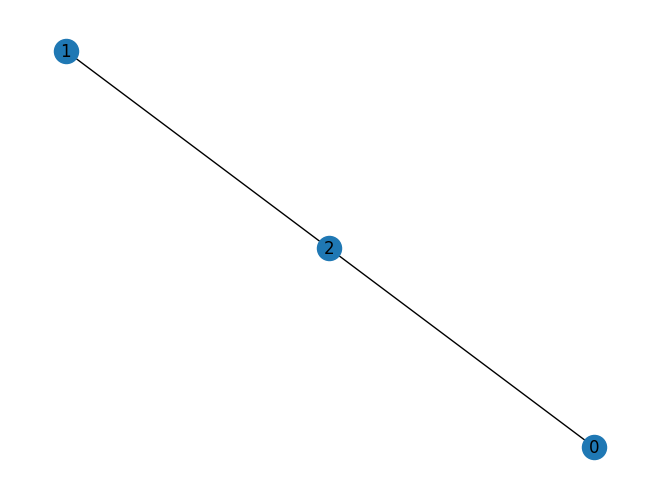

True

In [15]:
Pano = models.Panorama("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data copy/CMU0")
_ = Pano.detect()
_ = Pano.match_all_images()
M = Pano.match_ratio_matrix()
PG = models.PanoramaGraph(0.20)
PG.initialize_graph(M)
pu.plot_panorama_graph(PG)
PG.fully_connected

In [16]:
for i in range(len(Pano.image_files)): 
    neighbours = PG.get_k_closest_neighbors(i)
    i_name = Pano.get_file_name(i)
    neighbours_names = [Pano.get_file_name(n) for n in neighbours]
    print(f"{i_name}: {neighbours_names}")

medium11.JPG: ['medium12.JPG']
medium13.JPG: ['medium12.JPG']
medium12.JPG: ['medium11.JPG', 'medium13.JPG']


In [17]:
text = Pano.get_matching_stats_string()
print(text)

0 | medium11.JPG
	2 | medium12.JPG | 182.0 | 0.36
	1 | medium13.JPG | 38.0 | 0.08

1 | medium13.JPG
	2 | medium12.JPG | 140.0 | 0.28
	0 | medium11.JPG | 36.0 | 0.07

2 | medium12.JPG
	0 | medium11.JPG | 179.0 | 0.36
	1 | medium13.JPG | 173.0 | 0.35



In [18]:
Pano.generate_graph()

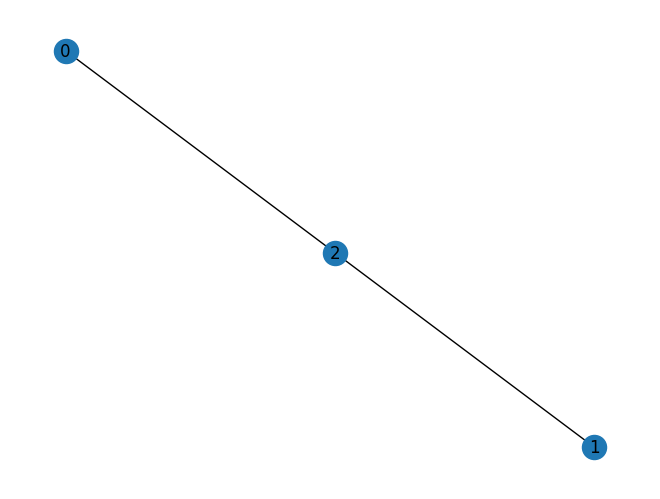

True

In [19]:
pu.plot_panorama_graph(Pano.PG)
Pano.PG.fully_connected

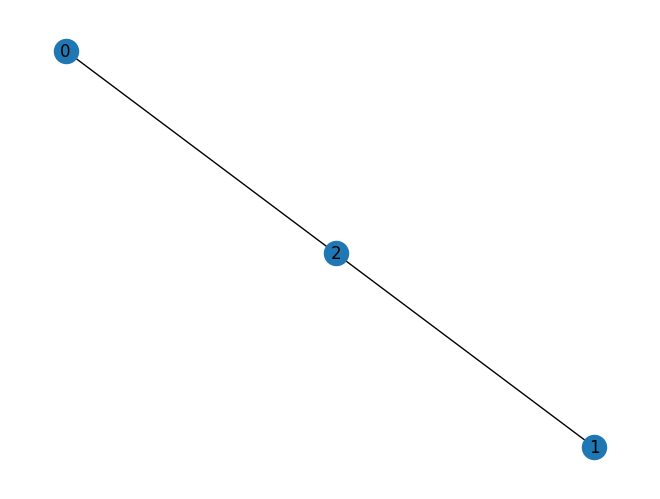

2


In [20]:
Pano.PG.keep_largest_connected_group()
pu.plot_panorama_graph(Pano.PG)
print(Pano.PG.base_node)

In [21]:
# view inlier amount
for u, v, data in Pano.PG.graph.edges(data=True):
    # data is a dict containing edge attributes
    a = len(Pano.get_sub_matching_df(u, v)) # total matches between - used to establisg possible connection
    b = len(Pano.get_image_pair_matches(u, v)) # total good matches - used to determine H
    ic = data.get("data")  
    ref, target = min(ic.reference, ic.target), max(ic.reference, ic.target)
    inliers = ic.inliers
    print(f"{ref} - {target} : {inliers} from {b} good matches from {a} initial matches")

0 - 2 : 128 from 237 good matches from 298 initial matches
1 - 2 : 124 from 212 good matches from 285 initial matches


In [22]:
# Pano.stitch_2(4, 5)

In [23]:
Pano.generate_panorama()

## Check Homographies

In [20]:
PG = Pano.PG

In [21]:
PG.get_homographies()

{2: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 4: array([[ 1.28604006e+00, -2.46077199e-02, -6.16632686e+02],
        [ 1.63343100e-01,  1.14162139e+00, -1.35782819e+02],
        [ 4.09827707e-04,  3.54747737e-06,  8.02923401e-01]]),
 5: array([[ 6.92822855e-01,  2.53423333e-02,  5.64438948e+02],
        [-1.03982250e-01,  9.05808266e-01,  3.62226954e+01],
        [-2.62702059e-04,  5.31673423e-06,  1.00000000e+00]]),
 7: array([[ 1.37923896e+00, -7.01163022e-02, -1.31838950e+03],
        [ 3.54570237e-01,  1.28383423e+00, -3.69052875e+02],
        [ 8.64277428e-04, -2.10844470e-05,  3.62251040e-01]]),
 10: array([[ 2.13330476e-01,  1.76599159e-02,  7.45715455e+02],
        [-1.41389861e-01,  6.37595021e-01,  1.97174715e+01],
        [-3.72854801e-04,  3.28437887e-06,  6.88619464e-01]]),
 11: array([[ 1.28570366e+00, -1.28560633e-01, -1.86893900e+03],
        [ 5.29970033e-01,  1.40752000e+00, -6.85925487e+02],
        [ 1.24614253e-03, -1.07336768e-04, -1.7242

In [78]:
ic = PG.get_image_connection(5,4)
ic

ImageConnection(weight=np.float64(0.488), inliers=0, valid_connection=<ValidConnection.UNKNOWN: -1>, homography=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), reference=4, target=5)

In [ ]:
Pano.PG.base_node

print(Pano.PG.get_image_connection(0,4))
print(Pano.PG.get_image_connection(5,4))
print(Pano.PG.get_image_connection(3,5))

array([[ 1.28604006e+00, -2.46077199e-02, -6.16632686e+02],
       [ 1.63343100e-01,  1.14162139e+00, -1.35782819e+02],
       [ 4.09827707e-04,  3.54747737e-06,  8.02923401e-01]])

# Complete

In [90]:
Pano = models.Panorama("/home/schmidtg/coding_projetcs/local-image-features-apps/src/image_stitching/datasets/example-data copy/flower")
Pano.generate_panorama()

In [91]:
Pano.PG.get_homographies()


{0: array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 3: array([[ 1.12053066e+00,  2.69031359e-01,  3.00638830e+02],
        [-2.01676932e-02,  1.27175236e+00, -5.51174463e+01],
        [-3.31935455e-05,  3.21730930e-04,  1.00000000e+00]]),
 2: array([[ 1.02964810e+00, -4.70871187e-02, -2.77039930e+02],
        [ 5.04756939e-02,  1.00501528e+00, -2.92423630e+01],
        [ 4.69710560e-05, -7.89717013e-08,  1.00000000e+00]]),
 1: array([[ 1.09274418e+00,  4.32420460e-01,  6.00151979e+02],
        [-5.94157628e-02,  1.33581384e+00, -2.48347586e+01],
        [-9.70855209e-05,  4.15373580e-04,  1.00000000e+00]])}

In [ ]:
Pano.